In [1]:
import pandas as pd

In [1]:
#pip install scikit-learn==1.0.0
#pip install statsmodels==0.12.2

Note: you may need to restart the kernel to use updated packages.


In [2]:
from nsepy import get_history as gh
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)
stk_data = gh(symbol='TATACOFFEE',start=start,end=end)


In [26]:
stk_data=stk_data[["Open","High","Low","Close"]]


In [27]:
stk_data

,Open,High,Low,Close
Date,,,,
2021-07-01,188.60,189.00,183.00,184.55
2021-07-02,183.05,187.50,182.15,186.40
2021-07-05,187.85,198.35,187.85,192.45
2021-07-06,193.80,194.80,187.35,188.80
2021-07-07,187.80,193.95,185.40,192.85
...,...,...,...,...
2022-01-21,217.70,224.40,216.70,219.55
2022-01-24,218.00,220.00,205.20,208.00
2022-01-25,207.50,213.70,200.00,211.90


In [5]:
column="Close"

In [6]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1= Ms.fit_transform(stk_data[[column]])
print("Len:",data1.shape)

Len: (145, 1)


In [7]:
len(data1)

145

In [8]:
training_size = round(len(data1 ) * 0.98)
print(training_size)
X_train=data1[:training_size]
X_test=data1[training_size:]
print("X_train length:",X_train.shape)
print("X_test length:",X_test.shape)
y_train=data1[:training_size]
y_test=data1[training_size:]
print("y_train length:",y_train.shape)
print("y_test length:",y_test.shape)

142
X_train length: (142, 1)
X_test length: (3, 1)
y_train length: (142, 1)
y_test length: (3, 1)


In [9]:
from sklearn.metrics import mean_squared_error
trends=['n','t','c','ct']
lags=[1,2,3,4]
from statsmodels.tsa.ar_model import AutoReg
for i in lags:
    #print(i)
   
    for td in trends:
        
        #print(td)
        #trendslist.append(td)
        model = AutoReg(X_train, lags=i,trend=td)
        model_fit = model.fit()
        # make prediction
        y_pred= model_fit.predict(len(X_train), len(data1)-1)
        #print(y_pred)
        #mse=mean_squared_error(y_test,y_pred,squared=False)
        from stockFunctions import rmsemape
        print("Lag={},Trend={}".format(i,td))
        rmsemape(y_test,y_pred)
        print("************")

C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

Lag=1,Trend=n
RMSE-Testset: 0.09721296906369806
maPe-Testset: 0.16908539716972681
************
Lag=1,Trend=t
RMSE-Testset: 0.036662297175603785
maPe-Testset: 0.05600888887166983
************
Lag=1,Trend=c
RMSE-Testset: 0.07242593535919618
maPe-Testset: 0.1262044792744375
************
Lag=1,Trend=ct
RMSE-Testset: 0.03749553966898969
maPe-Testset: 0.05992947542533802
************
Lag=2,Trend=n
RMSE-Testset: 0.09190677518435589
maPe-Testset: 0.15970455411009107
************
Lag=2,Trend=t
RMSE-Testset: 0.037730958235917975
maPe-Testset: 0.057716592715300524
************
Lag=2,Trend=c
RMSE-Testset: 0.07746569556051759
maPe-Testset: 0.13512037869532703
************
Lag=2,Trend=ct
RMSE-Testset: 0.0433241292359647
maPe-Testset: 0.0692397280767617
************
Lag=3,Trend=n
RMSE-Testset: 0.06980655740063893
maPe-Testset: 0.12255698557869088
************
Lag=3,Trend=t
RMSE-Testset: 0.03178694474180676
maPe-Testset: 0.04668268908477333
************
Lag=3,Trend=c
RMSE-Testset: 0.06611327649835042


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,
C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
 

In [10]:
len(y_pred)

3

In [11]:
i=4
td='c'
model = AutoReg(X_train, lags=i,trend=td)
model_fit = model.fit()
# make prediction
y_pred= model_fit.predict(len(X_train), len(data1)-1)
#print(y_pred)
from sklearn.metrics import r2_score
mse=mean_squared_error(y_test,y_pred,squared=False)
from stockFunctions import rmsemape
print("Lag={},Trend={}".format(i,td))
rmsemape(y_test,y_pred)
print("************")

Lag=4,Trend=c
RMSE-Testset: 0.07330940534791626
maPe-Testset: 0.12878755561117483
************


C:\Anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\ar_model.py:252: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  FutureWarning,


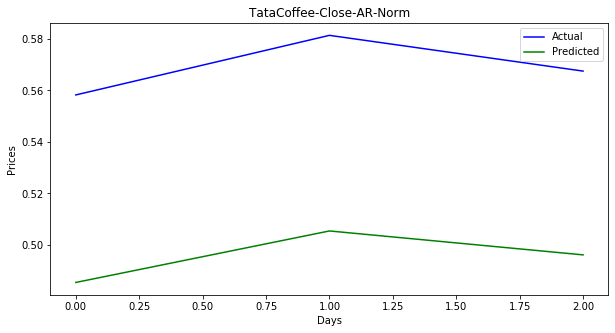

In [12]:
from stockFunctions import graph
graph(y_test,y_pred,"Actual","Predicted","TataCoffee-Close-AR-Norm","Days","Prices")

In [13]:
len(data1)

145

In [14]:
from stockFunctions import conversionSingle
aTestNormTable=conversionSingle(y_test,[column])
actual_stock_price_test_ori=Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA=conversionSingle(actual_stock_price_test_ori,[column])

In [15]:
from stockFunctions import conversionSingle
pTestNormTable=conversionSingle(y_pred,[column])
predicted_stock_price_test_ori=Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP=conversionSingle(predicted_stock_price_test_ori,[column])

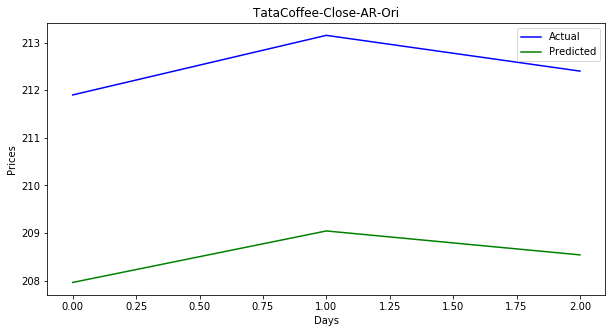

In [16]:
from stockFunctions import graph
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","TataCoffee-Close-AR-Ori","Days","Prices")

In [17]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA,predicted_stock_price_test_oriP)

RMSE-Testset: 3.966038829322264
maPe-Testset: 0.0186580448965511


In [22]:
forecast=model_fit.predict(len(data1), len(data1))

In [23]:
forecast

array([0.48550208, 0.50547335, 0.49619531, 0.49978364])

In [24]:
from stockFunctions import conversionSingle
fTestNormTable=conversionSingle(forecast,["Closefore"])
forecast_stock_price_test_ori=Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF=conversionSingle(forecast_stock_price_test_ori,["Closefore"])

In [25]:
forecast_stock_price_test_oriF

,Closefore
0,207.966
1,209.046
2,208.544
3,208.738


In [ ]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv",index=False)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[2000:2225], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label ="Predicted")